# OCR

Not every document contains machine-readable text.

A scanned PDF may look perfectly readable to a person while containing only page images. A normal PDF text parser can therefore return little or no useful text.

OCR — **Optical Character Recognition** — converts text visible in an image into machine-readable text.

For RAG, OCR is part of the ingestion pipeline:

```text
Scanned document
       ↓
Page image
       ↓
OCR
       ↓
Extracted text
       ↓
Cleaning / normalization
       ↓
Structure + provenance
       ↓
Chunking
       ↓
Retrieval
```

This notebook focuses on when OCR is needed, how to run it, how to inspect its output, and how to validate it.


## Learning Objectives

By the end of this notebook, you should be able to:

- Explain why OCR is needed for image-based documents.
- Distinguish a text PDF from an image-based PDF.
- Render PDF pages as images.
- Run OCR on document images.
- Inspect OCR output.
- Understand common OCR errors.
- Preserve page-level provenance.
- Clean and normalize OCR output conservatively.
- Validate OCR before sending it into a RAG pipeline.
- Decide when OCR is sufficient and when more advanced document understanding is required.


## 1. OCR in the Ingestion Pipeline

The important distinction is:

```text
Text PDF
    ↓
PDF parser
    ↓
Machine-readable text

Scanned PDF
    ↓
PDF parser
    ↓
Image
    ↓
OCR
    ↓
Machine-readable text
```

OCR is therefore a required stage for image-based content, not something every PDF needs.


## 2. Install the OCR Tools

We will use:

- **PyMuPDF** for low-level PDF operations and page rendering.
- **PyMuPDF4LLM** for LLM/RAG-oriented PDF extraction.
- **pytesseract** as the Python interface to Tesseract OCR.
- **Pillow** for working with images.

Install the Python packages with `!pip`.

> **Important:** `pymupdf4llm` is an LLM-oriented PDF extraction tool. It does not replace OCR when the useful content exists only as pixels.

In [1]:
!pip install -q pymupdf pymupdf4llm pytesseract pillow


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### OCR engine dependency

`pytesseract` is a Python wrapper. The actual OCR engine is **Tesseract**.

If Tesseract is not installed in your environment, `pytesseract` alone is not enough.

On a Linux environment where you have package-manager access:

```bash
apt-get update
apt-get install -y tesseract-ocr
```

OR

```bash
sudo apt-get update
sudo apt-get install -y tesseract-ocr
```

Managed notebook environments may already have Tesseract installed. We check rather than assuming.

In [2]:
import shutil

tesseract_path = shutil.which("tesseract")

if tesseract_path:
    print("Tesseract found:", tesseract_path)
else:
    print(
        "Tesseract was not found on PATH. "
        "Install the Tesseract system package before running OCR."
    )

Tesseract found: /usr/bin/tesseract


## 3. Import the Libraries

In [3]:
from pathlib import Path
import io
import re

import pymupdf
import pymupdf4llm
import pytesseract

from PIL import Image
from IPython.display import display

## 4. Choose the OCR Input Assets

For this lesson, we use two versions of the same document:

```text
data/
├── ravel_claim.png
└── scanned_travel_claim.pdf
```

The PNG demonstrates the fundamental OCR operation:

```text
Image
  ↓
OCR
  ↓
Text
```

The scanned PDF demonstrates the document-ingestion workflow:

```text
Scanned PDF
  ↓
PDF page
  ↓
Image
  ↓
OCR
  ↓
Text
```

The PDF contains an image rather than a machine-readable text layer.

In [4]:
DATA_DIR = Path("./data")

IMAGE_PATH = DATA_DIR / "travel_claim.png"
OCR_PDF_PATH = DATA_DIR / "scanned_travel_claim.pdf"

for path in (IMAGE_PATH, OCR_PDF_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Missing course asset: {path}")

print("Image asset:", IMAGE_PATH)
print("Scanned PDF:", OCR_PDF_PATH)


Image asset: data/travel_claim.png
Scanned PDF: data/scanned_travel_claim.pdf


### Inspect the Standalone Image

OCR operates on images, so first inspect the image directly.

Image mode: RGB
Image size: (1654, 2339)


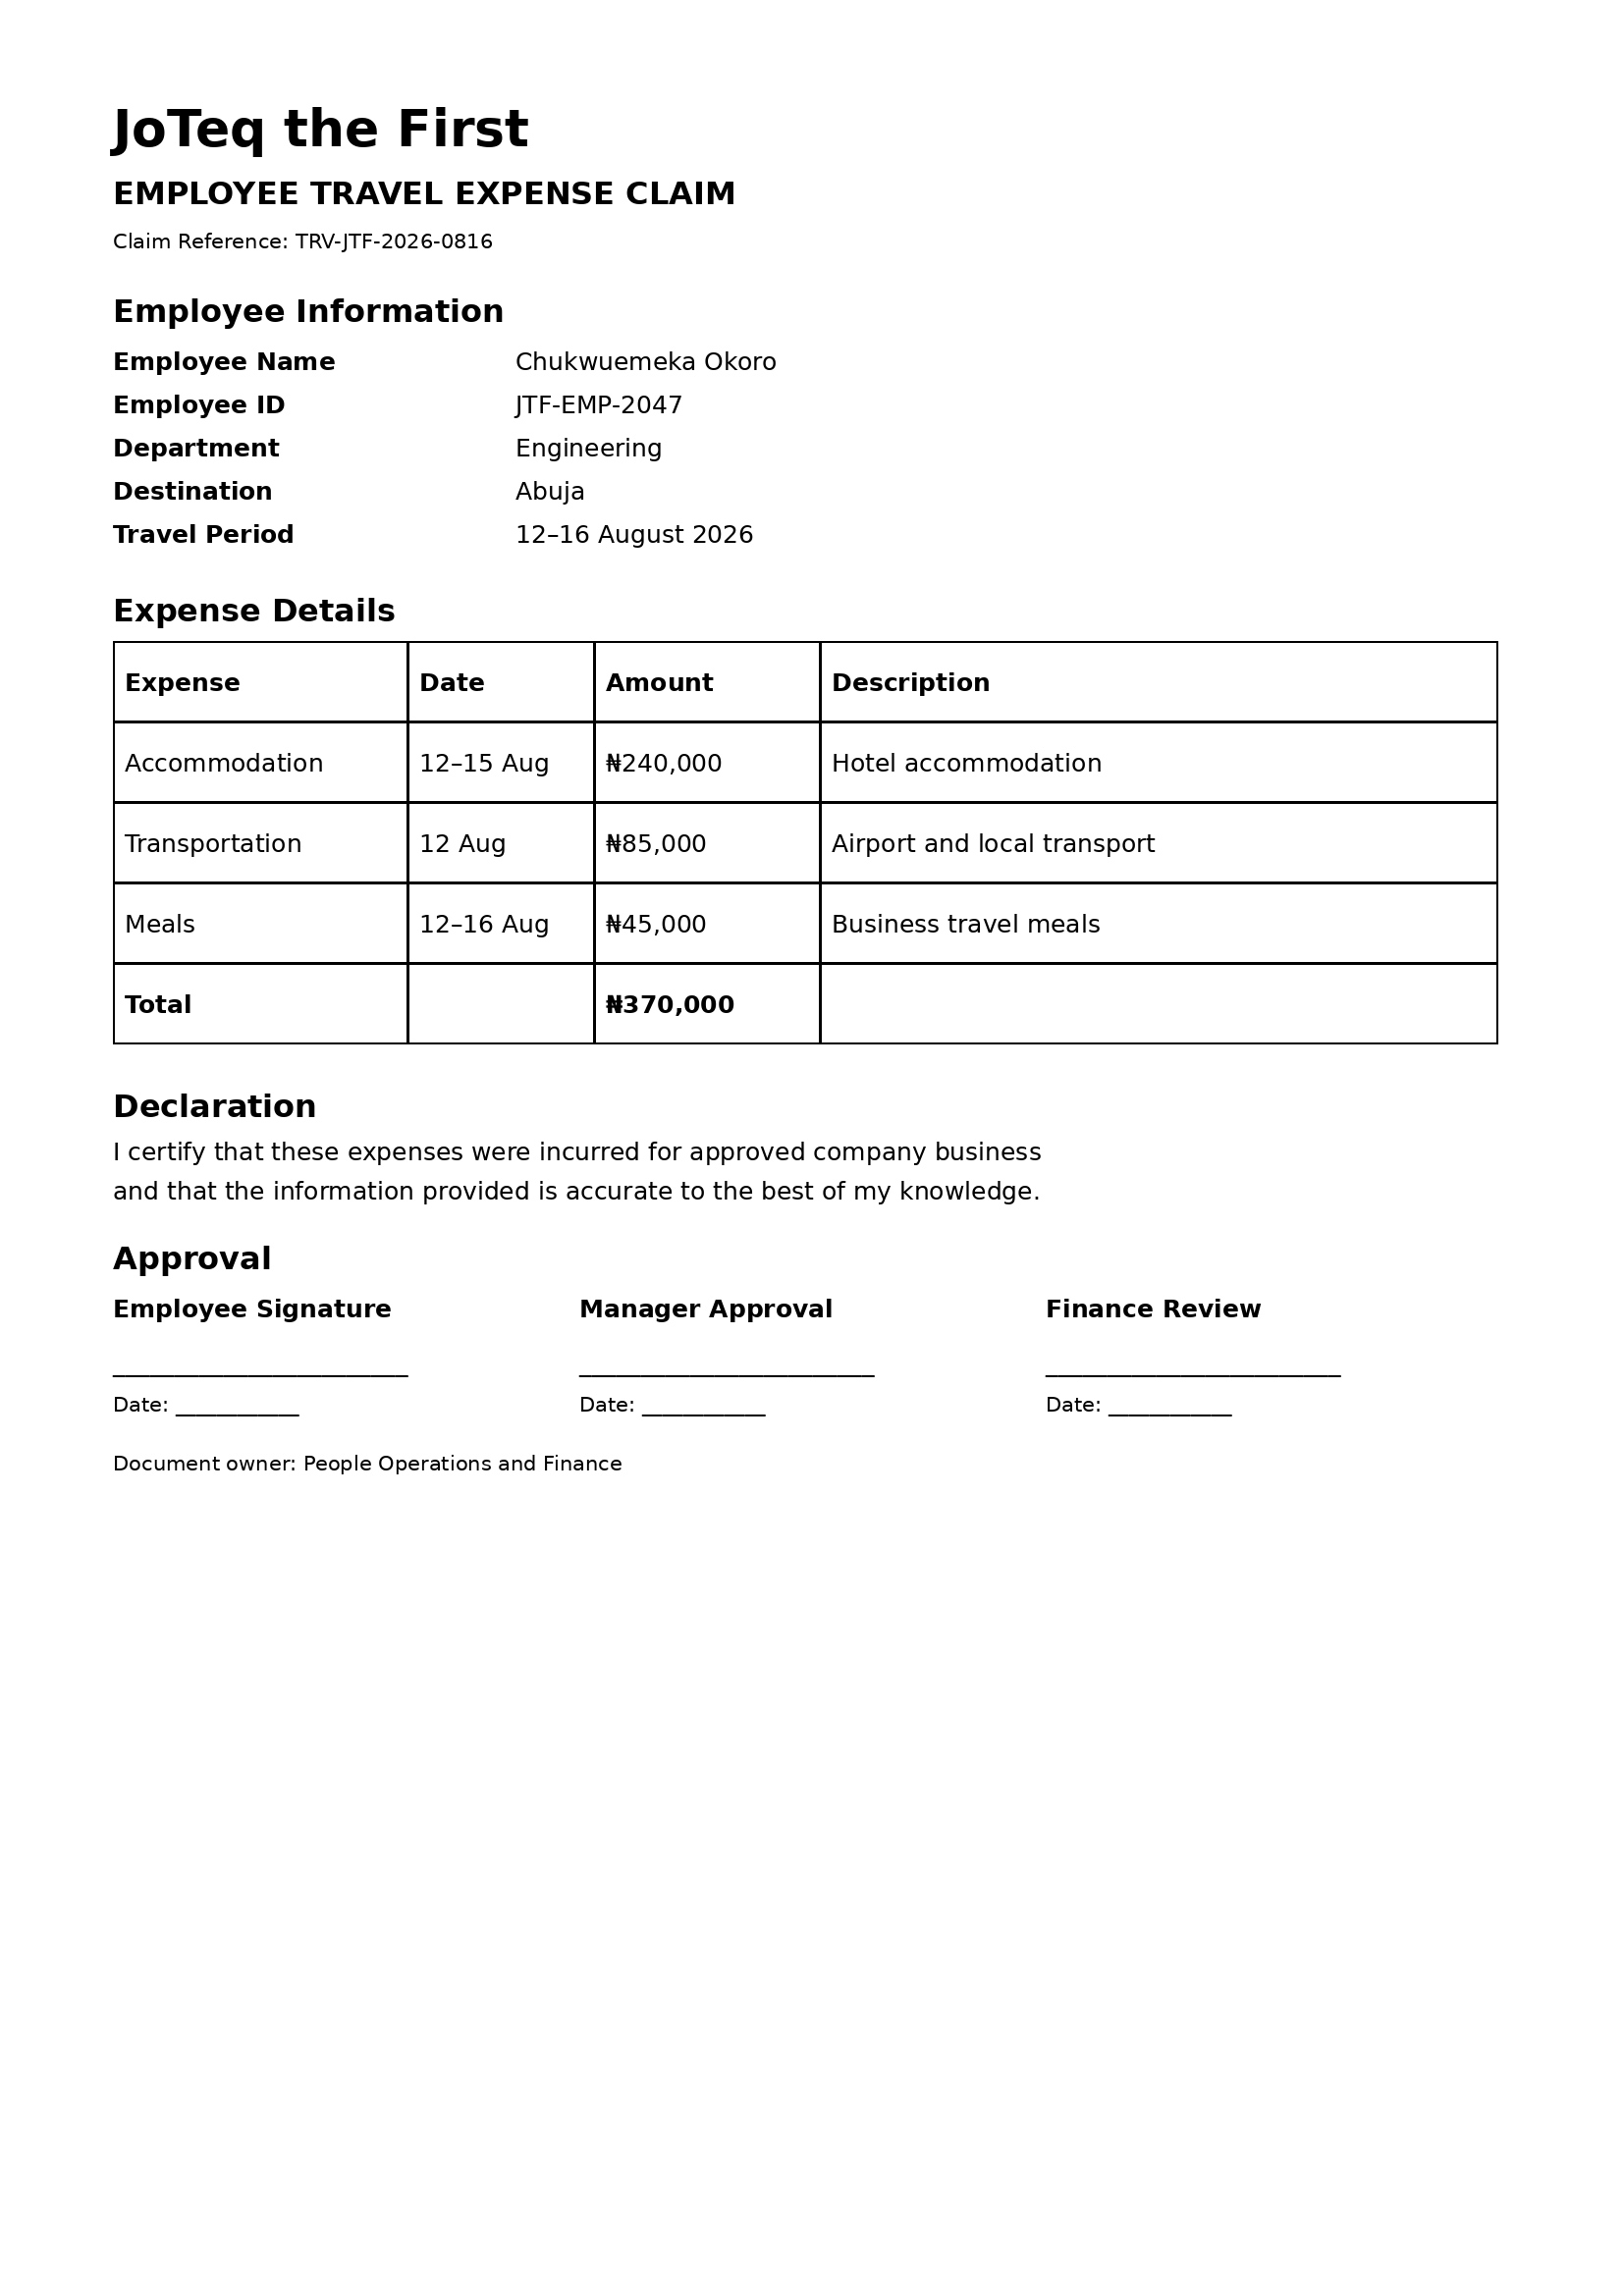

In [5]:
standalone_image = Image.open(IMAGE_PATH)

print("Image mode:", standalone_image.mode)
print("Image size:", standalone_image.size)

display(standalone_image)

### Verify the Scanned PDF

The scanned PDF should have no useful text layer.

In [6]:
with pymupdf.open(OCR_PDF_PATH) as document:
    for page_number, page in enumerate(document, start=1):
        text = page.get_text("text").strip()
        images = page.get_images(full=True)

        print({
            "page": page_number,
            "text_characters": len(text),
            "embedded_images": len(images),
        })

{'page': 1, 'text_characters': 0, 'embedded_images': 1}


The key distinction is:

```text
Standalone image
      ↓
      OCR

Scanned PDF
      ↓
contains image
      ↓
render/extract page image
      ↓
      OCR
```

The OCR engine receives an **image** in both cases.

## 5. Detect Whether OCR Is Needed

Before running OCR, inspect how much machine-readable text the PDF already contains.

This is only a diagnostic signal.

A page with little text may be:

- A scanned page
- A page containing mostly images
- A blank page
- A page with unusual encoding
- A page where extraction failed

So we combine text inspection with image inspection.


In [7]:
def inspect_pdf_text(pdf_path):
    results = []

    with pymupdf.open(pdf_path) as document:
        for page_number, page in enumerate(document, start=1):
            text = page.get_text("text").strip()
            images = page.get_images(full=True)

            results.append({
                "page_number": page_number,
                "text_characters": len(text),
                "embedded_images": len(images),
            })

    return results 

In [8]:
diagnostic_path = OCR_PDF_PATH
diagnostics = inspect_pdf_text(diagnostic_path)

for result in diagnostics:
    print(result)

{'page_number': 1, 'text_characters': 0, 'embedded_images': 1}


The important engineering principle is:

> **Do not run OCR simply because a document is a PDF. First determine whether machine-readable text is already available.**

## 6. Open the PDF and Inspect Its Pages

Let's open the selected document.

In [9]:
pdf = pymupdf.open(diagnostic_path)
print("Pages:", len(pdf))

Pages: 1


## 7. Render a Scanned PDF Page as an Image

The scanned PDF contains a page image.

For the PDF workflow, obtain the page image and then pass that image to OCR.

Rendered image size: (1190, 1684)


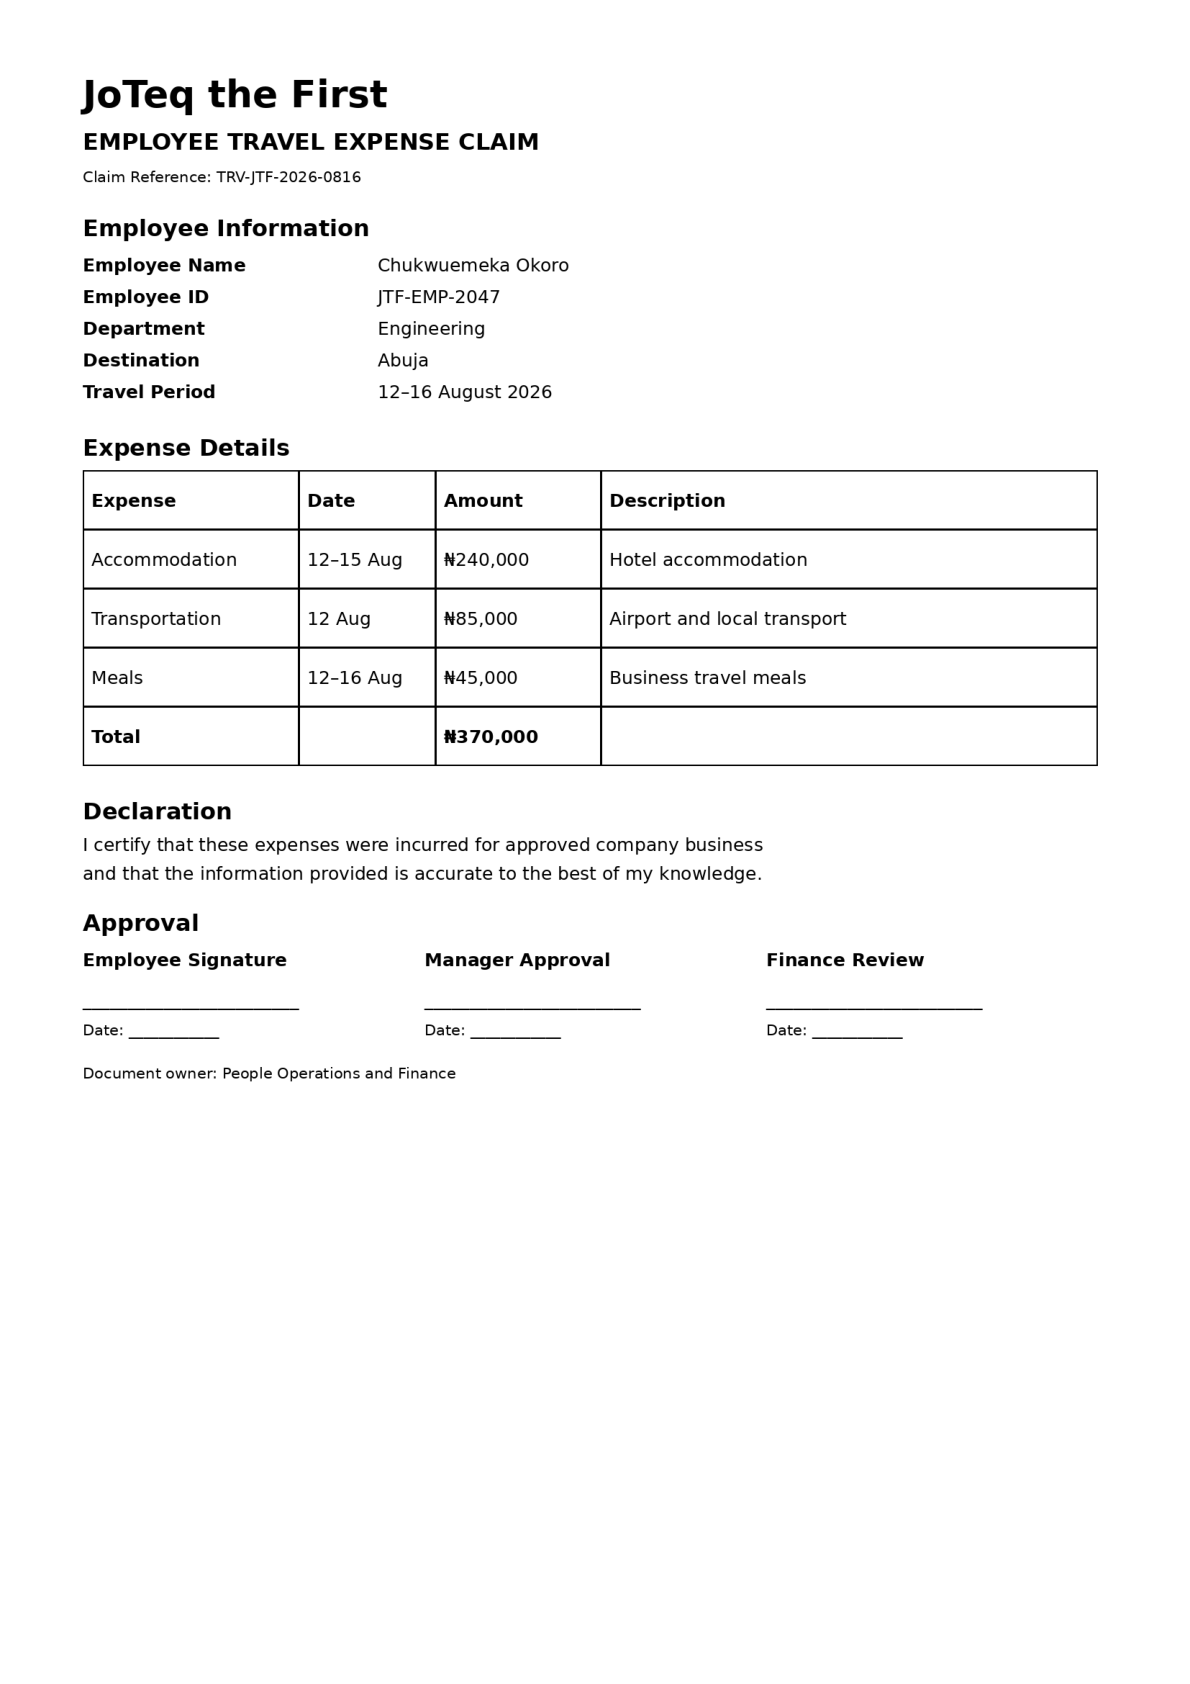

In [10]:
with pymupdf.open(OCR_PDF_PATH) as document:
    page = document[0]
    
    pixmap = page.get_pixmap(
        matrix=pymupdf.Matrix(2, 2),
        alpha=False,
    )

pdf_page_image = Image.open(
    io.BytesIO(pixmap.tobytes("png"))
)

print("Rendered image size:", pdf_page_image.size)
display(pdf_page_image)

Now the two OCR inputs are explicit:

```text
PNG ─────────────────→ OCR

Scanned PDF → page → image → OCR
```

## 8. Compare PDF Extraction with OCR

Before running OCR, test the scanned PDF with `pymupdf4llm`.

`pymupdf4llm` is useful for converting machine-readable PDF content into representations suitable for LLM applications, such as Markdown.

It is not an OCR engine.

For an image-only PDF, the useful content is still stored as pixels:

```text
Machine-readable PDF
        ↓
PyMuPDF / PyMuPDF4LLM
        ↓
Text / Markdown

Image-based PDF
        ↓
Page image
        ↓
OCR
        ↓
Text
```

In [11]:
markdown_output = pymupdf4llm.to_markdown(
    str(OCR_PDF_PATH)
)

print(markdown_output[:2000])


=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=0/1.


<!-- Start of picture text -->
JoTeq the First .<br><!-- End of picture text -->

## EMPLOYEE TRAVEL EXPENSE CLAIM 

Claim Reference: TRV-JTF-2026-0816 

# Employee Information 

Employee Name Chukwuemeka Okoro Employee ID JTF-EMP-2047 Department Engineering Destination Abuja Travel Period 12-16 August 2026 

# Expense Details 

||wees||Hotel accommodation|
|---|---|---|---|
|Transportation<br>|12 Aug<br>|N85,000<br>|Airport and local transport<br>|
|por|||wa70,000|Po|



### Declaration 

| certify that these expenses were incurred for approved company business and that the information provided is accurate to the best of my knowledge. 

# Approval 

Employee Signature Manager Approval Finance Review Date: Date: Date: 

Document owner: People Operations and Finance 




If the scanned document produces little or no useful text through `pymupdf4llm`, that is expected.

The document is not empty. Its content is visual, so we need an image-to-text step.

## 9. Run OCR

Now send the rendered image to Tesseract.

In [12]:
if not tesseract_path:
    print("Skipping OCR because Tesseract is not installed.")
else:
    ocr_text = pytesseract.image_to_string(pdf_page_image)
    print(ocr_text)

JoTeq the First

EMPLOYEE TRAVEL EXPENSE CLAIM

Claim Reference: TRV-JTF-2026-0816

Employee Information

Employee Name
Employee ID
Department
Destination
Travel Period

Expense Details

Chukwuemeka Okoro
JTF-EMP-2047

Engineering

Abuja

12-16 August 2026

Expense Date Amount Description
Accommodation 12-15 Aug N240,000 Hotel accommodation
Transportation 12 Aug N85,000 Airport and local transport
Meals 12-16 Aug 845,000 Business travel meals
Total 370,000
Declaration

| certify that these expenses were incurred for approved company business
and that the information provided is accurate to the best of my knowledge.

Approval

Employee Signature

Date:

Manager Approval

Finance Review

Date:

Document owner: People Operations and Finance

Date:




## 10. OCR with Page-Level Provenance

In a RAG system, OCR output should remain connected to the page that produced it.

Let's process pages individually.

In [13]:
def ocr_pdf_pages(pdf_path, scale=2):
    results = []

    with pymupdf.open(pdf_path) as document:
        for page_number, page in enumerate(document, start=1):
            pixmap = page.get_pixmap(
                matrix=pymupdf.Matrix(scale, scale),
                alpha=False,
            )

            image = Image.open(
                io.BytesIO(pixmap.tobytes("png"))
            )

            if not tesseract_path:
                text = ""
            else:
                text = pytesseract.image_to_string(image)

            results.append({
                "source": Path(pdf_path).name,
                "page_number": page_number,
                "text": text.strip(),
                "extraction_method": "tesseract_ocr",
            })
    return results

In [14]:
if tesseract_path:
    ocr_pages = ocr_pdf_pages(OCR_PDF_PATH)

    for page in ocr_pages:
        print(
            f"Page {page['page_number']}: "
            f"{len(page['text'])} characters"
        )
else:
    ocr_pages = []
    print("OCR execution skipped because Tesseract is not installed.")

Page 1: 754 characters


## 11. Inspect OCR Output

Never send OCR output directly into chunking without inspection.

Compare the OCR output against the original rendered page.

Ask:

- Are headings correct?
- Are numbers correct?
- Are dates correct?
- Is punctuation correct?
- Are lines in the correct order?
- Did OCR invent or omit text?

In [15]:
if ocr_pages:
    print(ocr_pages[0]["text"])
else:
    print("No OCR output available.")

JoTeq the First

EMPLOYEE TRAVEL EXPENSE CLAIM

Claim Reference: TRV-JTF-2026-0816

Employee Information

Employee Name
Employee ID
Department
Destination
Travel Period

Expense Details

Chukwuemeka Okoro
JTF-EMP-2047

Engineering

Abuja

12-16 August 2026

Expense Date Amount Description
Accommodation 12-15 Aug N240,000 Hotel accommodation
Transportation 12 Aug N85,000 Airport and local transport
Meals 12-16 Aug 845,000 Business travel meals
Total 370,000
Declaration

| certify that these expenses were incurred for approved company business
and that the information provided is accurate to the best of my knowledge.

Approval

Employee Signature

Date:

Manager Approval

Finance Review

Date:

Document owner: People Operations and Finance

Date:


## 12. Common OCR Errors

OCR is an extraction process and can misread visually similar characters.

Common examples include:

```text
O ↔ 0
I ↔ 1
S ↔ 5
B ↔ 8
```

Other errors can affect:

- Names
- Dates
- Currency
- Amounts
- Addresses
- Policy identifiers
- Punctuation

For RAG, errors in numbers and policy-critical terms can be especially dangerous.

## 13. OCR and Tables

OCR is particularly challenging for tables.

A table may visually contain:

```text
Location | Limit | Notes
---------|-------|------
...
```

but OCR may produce:

```text
Location Limit Notes
...
```

The words may be correct while the **row/column relationships are no longer explicit**.

Therefore:

> **OCR text extraction is not the same thing as table extraction.**

For difficult tables, OCR may need to be combined with layout-aware or table-aware document understanding.

## 14. OCR Confidence

Tesseract can provide word-level information, including confidence-related values.

Let's inspect the OCR data when Tesseract is available.

In [16]:
if not tesseract_path:
    print("Tesseract is not installed.")
else:
    ocr_data = pytesseract.image_to_data(
        pdf_page_image,
        output_type=pytesseract.Output.DICT,
    )

    for i, text in enumerate(ocr_data["text"]):
        text = text.strip()

        if not text:
            continue

        print({
            "text": text,
            "confidence": ocr_data["conf"][i],
            "left": ocr_data["left"][i],
            "top": ocr_data["top"][i],
            "width": ocr_data["width"][i],
            "height": ocr_data["height"][i],
        })

{'text': 'JoTeq', 'confidence': 88, 'left': 81, 'top': 80, 'width': 111, 'height': 35}
{'text': 'the', 'confidence': 96, 'left': 208, 'top': 78, 'width': 68, 'height': 30}
{'text': 'First', 'confidence': 96, 'left': 294, 'top': 78, 'width': 93, 'height': 30}
{'text': 'EMPLOYEE', 'confidence': 96, 'left': 85, 'top': 133, 'width': 133, 'height': 17}
{'text': 'TRAVEL', 'confidence': 96, 'left': 227, 'top': 133, 'width': 97, 'height': 17}
{'text': 'EXPENSE', 'confidence': 96, 'left': 335, 'top': 133, 'width': 114, 'height': 17}
{'text': 'CLAIM', 'confidence': 96, 'left': 459, 'top': 133, 'width': 78, 'height': 17}
{'text': 'Claim', 'confidence': 92, 'left': 83, 'top': 171, 'width': 41, 'height': 11}
{'text': 'Reference:', 'confidence': 93, 'left': 132, 'top': 171, 'width': 78, 'height': 11}
{'text': 'TRV-JTF-2026-0816', 'confidence': 86, 'left': 217, 'top': 171, 'width': 144, 'height': 14}
{'text': 'Employee', 'confidence': 96, 'left': 85, 'top': 219, 'width': 123, 'height': 22}
{'text': '

## 15. Basic OCR Cleaning

OCR output often contains accidental whitespace and repeated blank lines.

Cleaning should be conservative.

We should not aggressively "correct" text before understanding the extraction errors.

In [17]:
def clean_ocr_text(text):
    text = text.replace("\x00", "")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

In [18]:
if ocr_pages:
    cleaned_ocr_pages = []

    for page in ocr_pages:
        cleaned_ocr_pages.append({
            **page,
            "text": clean_ocr_text(page["text"]),
        })
    print(cleaned_ocr_pages[0]["text"])
else:
    cleaned_ocr_pages = []

JoTeq the First

EMPLOYEE TRAVEL EXPENSE CLAIM

Claim Reference: TRV-JTF-2026-0816

Employee Information

Employee Name
Employee ID
Department
Destination
Travel Period

Expense Details

Chukwuemeka Okoro
JTF-EMP-2047

Engineering

Abuja

12-16 August 2026

Expense Date Amount Description
Accommodation 12-15 Aug N240,000 Hotel accommodation
Transportation 12 Aug N85,000 Airport and local transport
Meals 12-16 Aug 845,000 Business travel meals
Total 370,000
Declaration

| certify that these expenses were incurred for approved company business
and that the information provided is accurate to the best of my knowledge.

Approval

Employee Signature

Date:

Manager Approval

Finance Review

Date:

Document owner: People Operations and Finance

Date:


There is an important difference between:

```text
Cleaning
```

and:

```text
Guessing what the source intended to say
```

Aggressive correction can introduce information that was never present in the source.


## 16. Validate OCR

A basic validation strategy compares:

```text
Rendered source
      ↓
OCR output
      ↓
Human / rule-based inspection
```

Useful checks include:

- Expected headings are present.
- Important identifiers are preserved.
- Dates are plausible.
- Numeric values are plausible.
- Required sections exist.
- Tables have not silently collapsed.
- OCR output is not unexpectedly short.

In [19]:
def basic_ocr_validation(text, minimum_characters=20):
    if not text.strip():
        return {
            "valid": False,
            "reason": "No text extracted",
        }

    if len(text.strip()) < minimum_characters:
        return {
            "valid": False,
            "reason": "Very little text extracted",
        }

    return {
        "valid": True,
        "characters": len(text.strip()),
    }

for page in cleaned_ocr_pages:
    print(
        f"Page {page['page_number']}:",
        basic_ocr_validation(page["text"])
    )

Page 1: {'valid': True, 'characters': 754}


This is only a starting point.

A production system should validate according to the document's domain and risk.

For example, an invoice pipeline may validate totals and currency, while a legal-document pipeline may validate section headings and clause identifiers.

## 17. OCR Fallback Strategy

A robust ingestion system should have explicit fallback behavior.

```text
Document
   ↓
Can text be extracted?
   │
  YES ───────────────→ Continue
   │
  NO
   ↓
Render page
   ↓
OCR
   ↓
Validate OCR
   │
 ┌─┴───────────────┐
 ↓                 ↓
Pass              Fail
 ↓                 ↓
Continue       Retry / alternate
               OCR / escalate
```

For difficult documents, escalation may involve:

- Different OCR settings
- Higher-resolution rendering
- Language-specific OCR models
- Layout-aware OCR
- Specialized document parsers
- Vision-language models
- Human review for critical information

## 18. Build a Normalized OCR Representation

OCR output should retain its provenance and extraction method.

In [20]:
normalized_ocr_document = {
    "source": OCR_PDF_PATH.name if OCR_PDF_PATH else diagnostic_path.name,
    "document_type": "pdf",
    "extraction_method": "ocr",
    "pages": [
        {
            "page_number": page["page_number"],
            "text": page["text"],
            "provenance": {
                "source": page["source"],
                "extraction_method": page["extraction_method"],
            },
        }
        for page in cleaned_ocr_pages
    ],
}

normalized_ocr_document

{'source': 'scanned_travel_claim.pdf',
 'document_type': 'pdf',
 'extraction_method': 'ocr',
 'pages': [{'page_number': 1,
   'text': 'JoTeq the First\n\nEMPLOYEE TRAVEL EXPENSE CLAIM\n\nClaim Reference: TRV-JTF-2026-0816\n\nEmployee Information\n\nEmployee Name\nEmployee ID\nDepartment\nDestination\nTravel Period\n\nExpense Details\n\nChukwuemeka Okoro\nJTF-EMP-2047\n\nEngineering\n\nAbuja\n\n12-16 August 2026\n\nExpense Date Amount Description\nAccommodation 12-15 Aug N240,000 Hotel accommodation\nTransportation 12 Aug N85,000 Airport and local transport\nMeals 12-16 Aug 845,000 Business travel meals\nTotal 370,000\nDeclaration\n\n| certify that these expenses were incurred for approved company business\nand that the information provided is accurate to the best of my knowledge.\n\nApproval\n\nEmployee Signature\n\nDate:\n\nManager Approval\n\nFinance Review\n\nDate:\n\nDocument owner: People Operations and Finance\n\nDate:',
   'provenance': {'source': 'scanned_travel_claim.pdf',
   

This makes an important distinction explicit:

```text
text extracted directly from PDF
```

versus:

```text
text reconstructed through OCR
```

That distinction can matter when debugging or assessing confidence in retrieved evidence.


## 19. OCR Is Not the End of Document Understanding

OCR answers:

> **What characters appear in this image?**

It does not necessarily answer:

> **What does the document's layout and structure mean?**

OCR alone may struggle with:

- Complex tables
- Forms
- Multi-column layouts
- Charts
- Diagrams
- Handwriting
- Visually grouped information

When structure matters, OCR may need to be combined with layout analysis or multimodal document understanding.


## 20. How OCR Errors Become RAG Errors

Consider:

```text
Scanned PDF
    ↓
OCR misreads a number
    ↓
Incorrect normalized text
    ↓
Incorrect chunk
    ↓
Incorrect embedding
    ↓
Retrieved as relevant
    ↓
LLM uses incorrect evidence
    ↓
Wrong answer
```

The retrieval system can appear to work correctly while the root problem is an OCR error.

This is why ingestion quality is part of RAG quality.


## 21. Exercise

Using the OCR document supplied with the course:

1. Determine whether the PDF contains machine-readable text.
2. Render one page as an image.
3. Run OCR on that page.
4. Compare the OCR output with the original image.
5. Identify at least three OCR errors or potential errors.
6. Inspect OCR confidence values.
7. Determine whether any table structure was lost.
8. Apply conservative cleaning.
9. Decide whether the result is good enough for RAG.
10. Explain what you would do if the OCR result failed validation.

The goal is not simply to run Tesseract.

The goal is to understand **when OCR output can be trusted and when it needs further processing**.


## Key Takeaways

1. OCR is needed when important document content exists as an image rather than machine-readable text.
2. A PDF should not automatically be sent through OCR.
3. PyMuPDF can render PDF pages into images.
4. OCR produces text, but extraction is not guaranteed to be correct.
5. OCR can introduce character, spacing, number, and layout errors.
6. OCR does not automatically reconstruct table semantics.
7. Confidence scores are useful signals but are not proof of correctness.
8. OCR output should retain page-level provenance and extraction method.
9. OCR should be validated before entering downstream RAG stages.
10. Difficult documents may require specialized parsing, layout analysis, VLMs, or human review.

## What's Next?

We can now handle the major distinction between:

```text
machine-readable document
```

and:

```text
image-based document → OCR
```

But extracted text is rarely ready for chunking immediately.

OCR and parsers can leave behind:

- Extra whitespace
- Broken line breaks
- Repeated headers
- Footers
- Encoding artifacts
- Inconsistent formatting
- Duplicated content

Next:

## Document Cleaning & Normalization

We will turn parser output into a cleaner, consistent representation while learning an important rule:

> **Clean the document without destroying information that retrieval needs.**
